# Minimal LmeEEG example

This notebook creates a simulated random-intercept EEG dataset, fits the minimal LmeEEG pipeline, runs permutation inference for the condition effect, and plots the results.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "lmeeeg").exists():
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root / "src"))

from lmeeeg.api.fit import fit_lmm_mass_univariate
from lmeeeg.api.infer import permute_fixed_effect
from lmeeeg.simulation.generator import simulate_random_intercept_dataset

In [19]:
simulated = simulate_random_intercept_dataset(
    n_subjects=10,
    n_trials_per_subject=12,
    n_channels=10,
    n_times=40,
    effect_channels=[2, 3],
    effect_times=range(12, 22),
    beta=1.0,
    seed=10,
)

print(f"EEG shape: {simulated.eeg.shape}")
simulated.metadata.head()

EEG shape: (120, 10, 40)


,subject,condition,latency
0,sub-000,A,-1.103338
1,sub-000,A,-0.725025
2,sub-000,A,-0.781805
3,sub-000,A,0.266976
4,sub-000,A,-0.248581


In [20]:
fit_result = fit_lmm_mass_univariate(
    eeg=simulated.eeg,
    metadata=simulated.metadata,
    formula="y ~ condition + latency + (1|subject)",
    variable_types={
        "condition": "categorical",
        "latency": "numeric",
        "subject": "group",
    },
)

fit_result.convergence_summary

ConvergenceSummary(n_features=400, n_converged=400, n_failed=0, convergence_rate=1.0, n_boundary_warnings=0)

In [21]:
inference = permute_fixed_effect(
    fit_result=fit_result,
    effect="condition[T.B]",
    correction="maxstat",
    n_permutations=100,
    seed=7,
)

print(f"Minimum corrected p-value: {np.nanmin(inference.corrected_p_values):.4f}")

Minimum corrected p-value: 0.0099


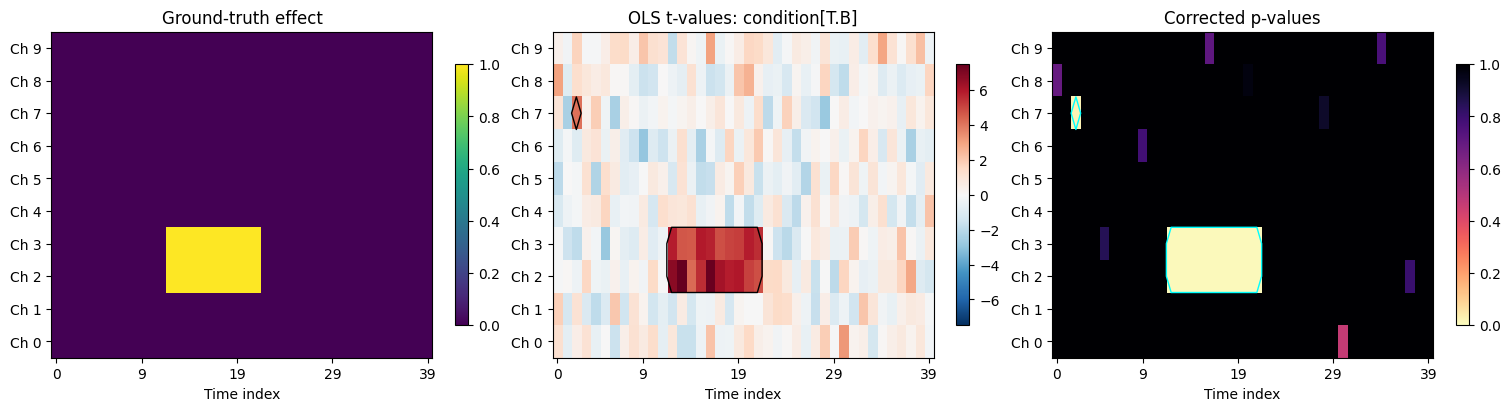

In [22]:
effect_name = "condition[T.B]"
t_map = fit_result.ols_t_values[effect_name]
p_map = inference.corrected_p_values
truth_map = simulated.ground_truth_effect

channel_labels = [f"Ch {index}" for index in range(truth_map.shape[0])]
time_axis = np.arange(truth_map.shape[1])
significant_mask = p_map < 0.05

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

panels = [
    (truth_map, "Ground-truth effect", "viridis"),
    (t_map, f"OLS t-values: {effect_name}", "RdBu_r"),
    (p_map, "Corrected p-values", "magma_r"),
]

for ax, (image, title, cmap) in zip(axes, panels):
    if title.startswith("OLS"):
        vmax = np.nanmax(np.abs(image))
        im = ax.imshow(image, aspect="auto", origin="lower", cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.contour(significant_mask.astype(float), levels=[0.5], colors="black", linewidths=1)
    elif title.startswith("Corrected"):
        im = ax.imshow(image, aspect="auto", origin="lower", cmap=cmap, vmin=0.0, vmax=1.0)
    else:
        im = ax.imshow(image, aspect="auto", origin="lower", cmap=cmap)

    ax.set_title(title)
    ax.set_xlabel("Time index")
    ax.set_xticks(np.linspace(0, len(time_axis) - 1, 5, dtype=int))
    ax.set_yticks(np.arange(len(channel_labels)))
    ax.set_yticklabels(channel_labels)
    fig.colorbar(im, ax=ax, shrink=0.8)

axes[2].contour(significant_mask.astype(float), levels=[0.5], colors="cyan", linewidths=1)
plt.show()